⏳ AI Model Load ho raha hai, kripya wait karein...
✅ Model 1 (Detector) Successfully Load ho gaya (Bina kisi error ke)!

🔍 Aapke diye gaye path par file check kar rahe hain...
✅ File mil gayi: brats20_dataset/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Validation_001_flair.nii

Evaluating NIfTI Image: brats20_dataset/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Validation_001_flair.nii


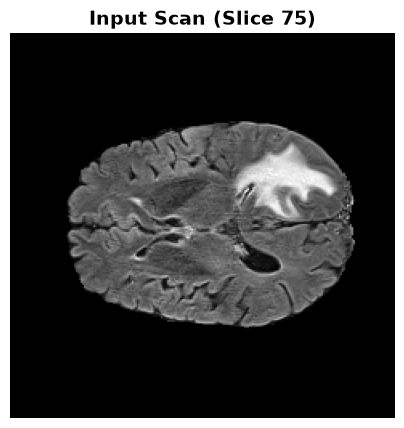


🧠 FINAL AI ANALYSIS REPORT (DETECTION ONLY)
🔎 Scanning for Tumor...
⚠️ Result: TUMOR DETECTED
📊 Detection Confidence: 100.00%


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
import nibabel as nib

print("⏳ AI Model Load ho raha hai, kripya wait karein...")

# --- TRICK: Bypassing the Keras 'batch_shape' bug by rebuilding architecture ---
def load_detector():
    """Model 1 (Tumor Detection) ka architecture"""
    model = Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    # Sirf weights load kar rahe hain, isse koi error nahi aayega
    model.load_weights('brain_tumor_detector_final.keras') 
    return model

# Global variable
detector_model = None

try:
    detector_model = load_detector()
    print("✅ Model 1 (Detector) Successfully Load ho gaya (Bina kisi error ke)!")
except Exception as e:
    print(f"\n❌ Error loading weights: {e}")
    print("Kripya check karein ki 'brain_tumor_detector_final.keras' current folder me hai ya nahi.")

# --- MAIN PIPELINE FUNCTION ---
def analyze_nifti_scan(nifti_path, slice_index=75):
    
    if detector_model is None:
        print("❌ Model load nahi hua, isliye prediction aage nahi badh sakti.")
        return
        
    print(f"\nEvaluating NIfTI Image: {nifti_path}")
    
    try:
        nifti_img = nib.load(nifti_path)
        img_data = nifti_img.get_fdata()
        
        if len(img_data.shape) != 3:
            print("❌ The NIfTI file does not contain a 3D volume.")
            return
            
    except Exception as e:
        print(f"❌ Error loading .nii file: {e}")
        return

    if slice_index >= img_data.shape[2]:
         print(f"❌ Error: Slice index {slice_index} is out of bounds (Max is {img_data.shape[2]-1})")
         return

    slice_2d = img_data[:, :, slice_index]

    if np.max(slice_2d) > 0:
        slice_2d_norm = (slice_2d / np.max(slice_2d)) * 255.0
    else:
        slice_2d_norm = slice_2d * 0
        
    slice_2d_norm = slice_2d_norm.astype(np.uint8)
    img_rgb = cv2.cvtColor(slice_2d_norm, cv2.COLOR_GRAY2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Input Scan (Slice {slice_index})", fontsize=14, fontweight='bold')
    plt.show()

    print("\n" + "="*40)
    print("🧠 FINAL AI ANALYSIS REPORT (DETECTION ONLY)")
    print("="*40)

    img_det = cv2.resize(img_rgb, (128, 128))
    img_det = img_det / 255.0  
    img_det = np.expand_dims(img_det, axis=0) 

    print("🔎 Scanning for Tumor...")
    det_prediction = detector_model.predict(img_det, verbose=0)[0][0]

    if det_prediction < 0.5:
        confidence = (1 - det_prediction) * 100
        print(f"✅ Result: HEALTHY BRAIN (No Tumor Detected)")
        print(f"📊 Confidence: {confidence:.2f}%")
    else:
        confidence = det_prediction * 100
        print(f"⚠️ Result: TUMOR DETECTED")
        print(f"📊 Detection Confidence: {confidence:.2f}%")
        
    print("="*40)


# --- TEST THE PIPELINE WITH EXACT PATH ---
print("\n🔍 Aapke diye gaye path par file check kar rahe hain...")

# Aapka diya hua exact relative path
test_nifti_path = 'brats20_dataset/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Validation_001_flair.nii'

# Check karte hain ki kya ye file sach me wahan exist karti hai
if os.path.exists(test_nifti_path):
    print(f"✅ File mil gayi: {test_nifti_path}")
    # Agar file khali (0 bytes) nahi hai, toh aage badho
    if os.path.getsize(test_nifti_path) > 0:
        analyze_nifti_scan(test_nifti_path, slice_index=75)
    else:
        print("❌ Error: File mil gayi par wo khali (0 bytes) hai.")
else:
    print(f"❌ Error: File is path par nahi mili: {test_nifti_path}")
    print(f"💡 Info: Aapki script abhi is folder me run ho rahi hai: {os.getcwd()}")
    print("Kripya check karein ki 'brats20_dataset' folder isi directory ke andar hona chahiye.")

Loading Classifier Model Safely...
✅ Model loaded successfully without errors!


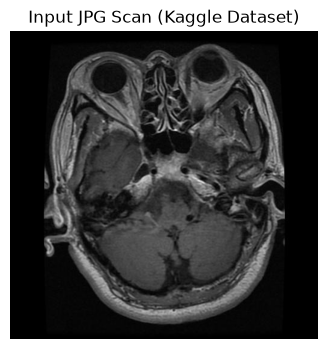


🔬 Analyzing Tumor Type...
🔴 Correct Tumor Type Prediction: Pituitary Tumor
📊 Confidence: 94.93%


In [2]:
# Model 2 Predict type of brain tumer
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("Loading Classifier Model Safely...")

# --- TRICK: Bypassing the 'batch_shape' bug by rebuilding architecture ---
base_model = MobileNetV2(weights=None, include_top=False, input_shape=(224, 224, 3))
classifier_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), 
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Ab hum safe tarike se sirf weights load kar rahe hain
try:
    classifier_model.load_weights('tumor_classifier_final.keras')
    print("✅ Model loaded successfully without errors!")
except Exception as e:
    print(f"❌ Weights load nahi hue. Error: {e}")

CLASS_NAMES = ['Glioma Tumor', 'Meningioma Tumor', 'Healthy (No Tumor)', 'Pituitary Tumor']

# Kaggle ke testing folder se ek asli JPG image uthate hain
test_jpg_path = 'Classification_dataset/pituitary_tumor/p (2).jpg'

img = cv2.imread(test_jpg_path)

if img is None:
    print("❌ Error: Image nahi mili. Kripya image ka path check karein.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Input JPG Scan (Kaggle Dataset)")
    plt.show()

    img_class = cv2.resize(img_rgb, (224, 224))
    img_class = np.expand_dims(img_class, axis=0)
    img_class = preprocess_input(img_class)

    print("\n🔬 Analyzing Tumor Type...")
    class_prediction = classifier_model.predict(img_class, verbose=0)
    best_class_index = np.argmax(class_prediction, axis=1)[0]
    class_confidence = class_prediction[0][best_class_index] * 100
    predicted_tumor_type = CLASS_NAMES[best_class_index]

    print(f"🔴 Correct Tumor Type Prediction: {predicted_tumor_type}")
    print(f"📊 Confidence: {class_confidence:.2f}%")